In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import shutil
from pathlib import Path
import random

In [2]:
df=pd.read_csv("/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train_labels.csv")
print(df.columns)
print(df.head(10))
print(df.shape)

Index(['row_id', 'tomo_id', 'Motor axis 0', 'Motor axis 1', 'Motor axis 2',
       'Array shape (axis 0)', 'Array shape (axis 1)', 'Array shape (axis 2)',
       'Voxel spacing', 'Number of motors'],
      dtype='object')
   row_id      tomo_id  Motor axis 0  Motor axis 1  Motor axis 2  \
0       0  tomo_003acc          -1.0          -1.0          -1.0   
1       1  tomo_00e047         169.0         546.0         603.0   
2       2  tomo_00e463         235.0         403.0         137.0   
3       3  tomo_00e463         243.0         363.0         153.0   
4       4  tomo_00e463         222.0         379.0         144.0   
5       5  tomo_00e463         225.0         262.0         628.0   
6       6  tomo_00e463         225.0         241.0         643.0   
7       7  tomo_00e463         231.0         289.0         632.0   
8       8  tomo_01a877         147.0         638.0         286.0   
9       9  tomo_02862f         101.0         351.0         120.0   

   Array shape (axis 0)  Arra

In [3]:
print("Total tomograms:", df['tomo_id'].nunique())
print("Tomograms with no motor:", (df['Number of motors'] == 0).sum())
print("Tomograms with motors:", (df['Number of motors'] > 0).sum())
print("\nMotor count distribution:")
print(df['Number of motors'].value_counts())

Total tomograms: 648
Tomograms with no motor: 286
Tomograms with motors: 451

Motor count distribution:
Number of motors
1     313
0     286
2      56
4      36
6      18
3      18
10     10
Name: count, dtype: int64


In [4]:
# Pick a tomogram with 1 motor
sample = df[df['Number of motors'] == 1].iloc[0]
tomo_id = sample['tomo_id']
motor_z = int(sample['Motor axis 0'])
print(tomo_id, motor_z, sample)



tomo_00e047 169 row_id                            1
tomo_id                 tomo_00e047
Motor axis 0                  169.0
Motor axis 1                  546.0
Motor axis 2                  603.0
Array shape (axis 0)            300
Array shape (axis 1)            959
Array shape (axis 2)            928
Voxel spacing                  15.6
Number of motors                  1
Name: 1, dtype: object


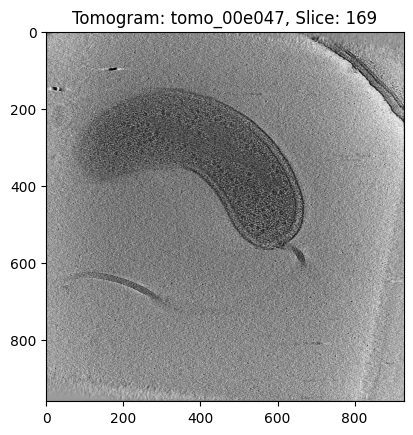

In [5]:
# Load that specific slice
slice_path = "/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train/tomo_00e047/slice_0169.jpg"
img = Image.open(slice_path)
plt.imshow(img, cmap='gray')
plt.title(f'Tomogram: {tomo_id}, Slice: {motor_z}')
plt.show()

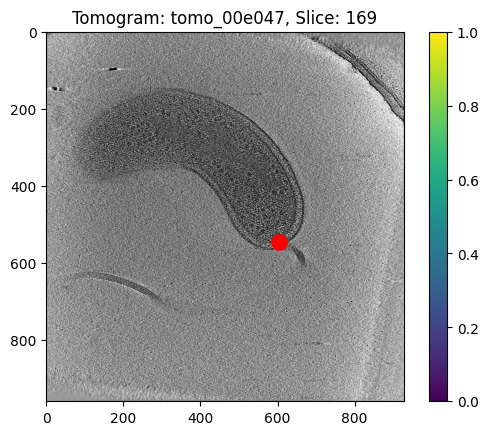

In [6]:
motor_y = int(sample['Motor axis 1'])
motor_x = int(sample['Motor axis 2'])

plt.imshow(img, cmap='gray')
plt.scatter(motor_x, motor_y, c='red', s=100, marker='o', linewidths=2)
plt.title(f'Tomogram: {tomo_id}, Slice: {motor_z}')
plt.colorbar()
plt.show()

In [7]:
slice_path = "/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train/tomo_00e047/slice_0169.jpg"
img = Image.open(slice_path)
print("Image size (width, height):", img.size)
print("Image mode:", img.mode)

Image size (width, height): (928, 959)
Image mode: L


In [8]:
img_w, img_h = 928, 959
box_size = 50

motor_x = int(sample['Motor axis 2'])
motor_y = int(sample['Motor axis 1'])

x_center = motor_x / img_w
y_center = motor_y / img_h
width = box_size / img_w
height = box_size / img_h

print(f"YOLO label: 0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}")

YOLO label: 0 0.6498 0.5693 0.0539 0.0521


In [9]:
output_dir = '/kaggle/working/yolo_dataset'
img_out = f'{output_dir}/images/train'
lbl_out = f'{output_dir}/labels/train'
os.makedirs(img_out, exist_ok=True)
os.makedirs(lbl_out, exist_ok=True)

print("Directories created!")
print(os.listdir(output_dir))

Directories created!
['labels', 'images']


In [10]:
box_size = 50
train_path = '/kaggle/input/byu-locating-bacterial-flagellar-motors-2025/train'

# Only process rows WITH motors
motors_df = df[df['Number of motors'] > 0].copy()

for idx, row in motors_df.iterrows():
    tomo_id = row['tomo_id']
    motor_z = int(row['Motor axis 0'])
    motor_x = int(row['Motor axis 2'])
    motor_y = int(row['Motor axis 1'])
    img_w = int(row['Array shape (axis 2)'])
    img_h = int(row['Array shape (axis 1)'])
    
    # Image path
    slice_path = f'{train_path}/{tomo_id}/{motor_z:04d}.jpg'
    if not os.path.exists(slice_path):
        continue
    
    # Unique filename per row
    fname = f'{tomo_id}_z{motor_z}_idx{idx}'
    
    # Copy image
    shutil.copy(slice_path, f'{img_out}/{fname}.jpg')
    
    # Write YOLO label
    x_center = motor_x / img_w
    y_center = motor_y / img_h
    w = box_size / img_w
    h = box_size / img_h
    
    with open(f'{lbl_out}/{fname}.txt', 'w') as f:
        f.write(f'0 {x_center:.4f} {y_center:.4f} {w:.4f} {h:.4f}\n')

print(f"Done! Processed {len(motors_df)} motor slices")

Done! Processed 451 motor slices


In [11]:
print(os.path.exists(img_out))
print(os.path.exists(lbl_out))
print(img_out)
print(lbl_out)

True
True
/kaggle/working/yolo_dataset/images/train
/kaggle/working/yolo_dataset/labels/train


In [12]:
# Check what's actually in the train folder
train_path = '/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train'

# List first tomogram
tomos = os.listdir(train_path)
print("First few tomograms:", tomos[:3])

# Look inside first tomogram
first_tomo = tomos[0]
slices = os.listdir(f'{train_path}/{first_tomo}')
print(f"\nFirst few slices in {first_tomo}:", slices[:5])

First few tomograms: ['tomo_ef1a1a', 'tomo_6607ec', 'tomo_47ac94']

First few slices in tomo_ef1a1a: ['slice_0273.jpg', 'slice_0018.jpg', 'slice_0185.jpg', 'slice_0252.jpg', 'slice_0214.jpg']


In [13]:
box_size = 50
train_path = '/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train'
motors_df = df[df['Number of motors'] > 0].copy()

for idx, row in motors_df.iterrows():
    tomo_id = row['tomo_id']
    motor_z = int(row['Motor axis 0'])
    motor_x = int(row['Motor axis 2'])
    motor_y = int(row['Motor axis 1'])
    img_w = int(row['Array shape (axis 2)'])
    img_h = int(row['Array shape (axis 1)'])
    
    # FIXED path with slice_ prefix
    slice_path = f'{train_path}/{tomo_id}/slice_{motor_z:04d}.jpg'
    if not os.path.exists(slice_path):
        continue
    
    fname = f'{tomo_id}_z{motor_z}_idx{idx}'
    shutil.copy(slice_path, f'{img_out}/{fname}.jpg')
    
    x_center = motor_x / img_w
    y_center = motor_y / img_h
    w = box_size / img_w
    h = box_size / img_h
    
    with open(f'{lbl_out}/{fname}.txt', 'w') as f:
        f.write(f'0 {x_center:.4f} {y_center:.4f} {w:.4f} {h:.4f}\n')

print(f"Done! Processed {len(motors_df)} motor slices")

Done! Processed 451 motor slices


In [14]:
images = os.listdir(img_out)
labels = os.listdir(lbl_out)
print(f"Total images: {len(images)}")
print(f"Total labels: {len(labels)}")
print(f"\nSample image: {images[0]}")
print(f"Sample label: {labels[0]}")

Total images: 451
Total labels: 451

Sample image: tomo_cf0875_z41_idx598.jpg
Sample label: tomo_d26fcb_z118_idx609.txt


In [15]:
random.seed(42)

# Create val directories
img_val = f'{output_dir}/images/val'
lbl_val = f'{output_dir}/labels/val'
os.makedirs(img_val, exist_ok=True)
os.makedirs(lbl_val, exist_ok=True)

# Shuffle and split
all_images = os.listdir(img_out)
random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_files = all_images[:split]
val_files = all_images[split:]

print(f"Train: {len(train_files)}, Val: {len(val_files)}")

Train: 360, Val: 91


In [16]:
for fname in val_files:
    # Move image
    shutil.move(f'{img_out}/{fname}', f'{img_val}/{fname}')
    
    # Move corresponding label
    label_fname = fname.replace('.jpg', '.txt')
    shutil.move(f'{lbl_out}/{label_fname}', f'{lbl_val}/{label_fname}')

# Verify
print(f"Train images: {len(os.listdir(img_out))}")
print(f"Train labels: {len(os.listdir(lbl_out))}")
print(f"Val images: {len(os.listdir(img_val))}")
print(f"Val labels: {len(os.listdir(lbl_val))}")

Train images: 360
Train labels: 360
Val images: 91
Val labels: 91


In [17]:
yaml_content = f"""
path: {output_dir}
train: images/train
val: images/val

nc: 1
names: ['motor']
"""

with open(f'{output_dir}/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("YAML created!")
print(yaml_content)

YAML created!

path: /kaggle/working/yolo_dataset
train: images/train
val: images/val

nc: 1
names: ['motor']



In [18]:
# Install ultralytics
!pip install ultralytics -q

from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train!
results = model.train(
    data=f'{output_dir}/dataset.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    project='/kaggle/working/yolo_runs',
    name='flagellar_motors',
    exist_ok=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=

Prediction images found: ['/kaggle/working/yolo_runs/flagellar_motors/val_batch2_pred.jpg', '/kaggle/working/yolo_runs/flagellar_motors/val_batch2_labels.jpg', '/kaggle/working/yolo_runs/flagellar_motors/val_batch1_labels.jpg', '/kaggle/working/yolo_runs/flagellar_motors/val_batch0_labels.jpg', '/kaggle/working/yolo_runs/flagellar_motors/val_batch0_pred.jpg', '/kaggle/working/yolo_runs/flagellar_motors/val_batch1_pred.jpg']


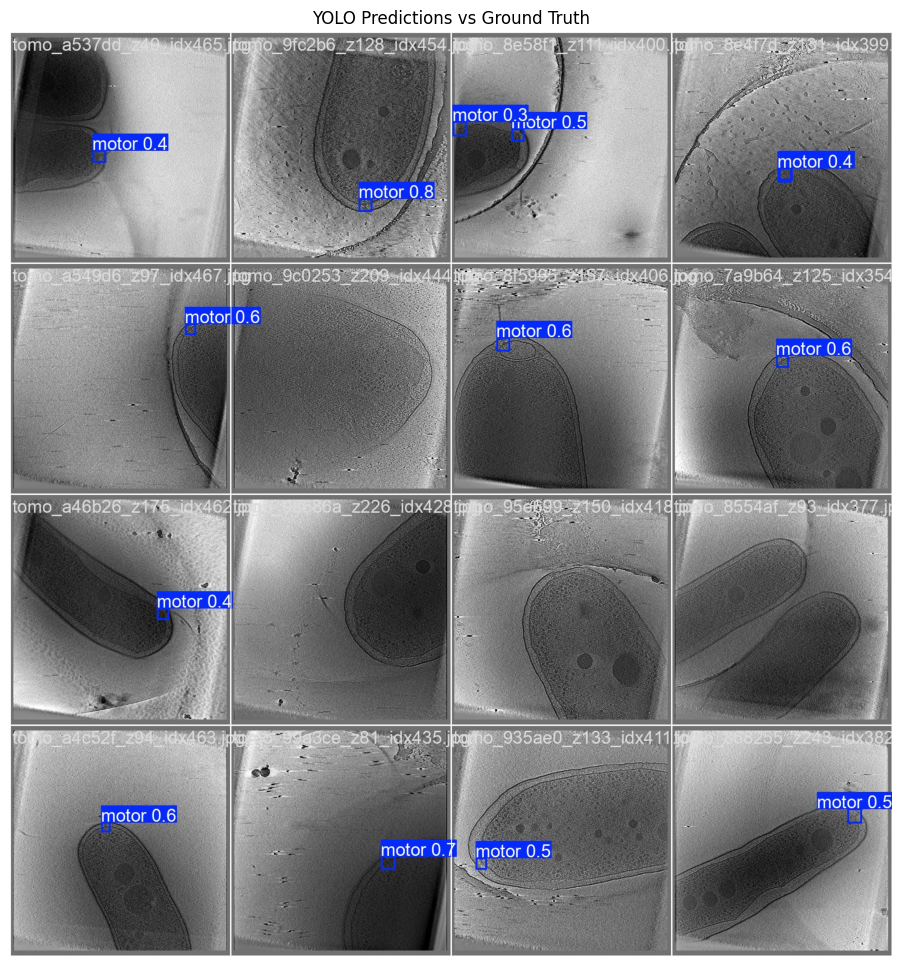

In [19]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Find validation prediction images
pred_imgs = glob.glob('/kaggle/working/yolo_runs/flagellar_motors/val_batch*.jpg')
print("Prediction images found:", pred_imgs)

# Show first one
if pred_imgs:
    img = Image.open(pred_imgs[0])
    plt.figure(figsize=(12,12))
    plt.imshow(img)
    plt.axis('off')
    plt.title('YOLO Predictions vs Ground Truth')
    plt.show()

In [20]:
# Check test data structure
test_path = '/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/test'
test_tomos = os.listdir(test_path)
print(f"Total test tomograms: {len(test_tomos)}")
print(f"First few: {test_tomos[:5]}")

# Check sample submission format
sample_sub = pd.read_csv('/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/sample_submission.csv')
print(f"\nSample submission shape: {sample_sub.shape}")
print(sample_sub.head(10))

Total test tomograms: 3
First few: ['tomo_01a877', 'tomo_00e047', 'tomo_003acc']

Sample submission shape: (3, 4)
       tomo_id  Motor axis 0  Motor axis 1  Motor axis 2
0  tomo_003acc           100           100           100
1  tomo_00e047           100           100           100
2  tomo_01a877           100           100           100


In [21]:
from ultralytics import YOLO
import numpy as np

# Load best model
model = YOLO('/kaggle/working/yolo_runs/flagellar_motors/weights/best.pt')

results_list = []

for tomo_id in test_tomos:
    tomo_path = f'{test_path}/{tomo_id}'
    slices = sorted(os.listdir(tomo_path))
    
    best_conf = 0
    best_pred = None
    
    for slice_name in slices:
        slice_path = f'{tomo_path}/{slice_name}'
        z = int(slice_name.replace('slice_', '').replace('.jpg', ''))
        
        result = model(slice_path, verbose=False)[0]
        
        if len(result.boxes) > 0:
            for box in result.boxes:
                conf = float(box.conf)
                if conf > best_conf:
                    best_conf = conf
                    x_center = float(box.xywh[0][0])
                    y_center = float(box.xywh[0][1])
                    best_pred = (z, y_center, x_center)
    
    if best_pred:
        results_list.append({'tomo_id': tomo_id, 'Motor axis 0': best_pred[0], 
                            'Motor axis 1': best_pred[1], 'Motor axis 2': best_pred[2]})
    else:
        results_list.append({'tomo_id': tomo_id, 'Motor axis 0': -1, 
                            'Motor axis 1': -1, 'Motor axis 2': -1})

submission = pd.DataFrame(results_list)
print(submission)

       tomo_id  Motor axis 0  Motor axis 1  Motor axis 2
0  tomo_01a877           147    634.815735    287.447021
1  tomo_00e047           115    376.649048    138.699783
2  tomo_003acc           106    980.507935    771.369812


In [22]:
# Save submission
submission.to_csv('/kaggle/working/submission.csv', index=False)
print("Submission saved!")
print(submission)

# Verify format matches sample
print("\nSample submission columns:", sample_sub.columns.tolist())
print("Our submission columns:", submission.columns.tolist())

Submission saved!
       tomo_id  Motor axis 0  Motor axis 1  Motor axis 2
0  tomo_01a877           147    634.815735    287.447021
1  tomo_00e047           115    376.649048    138.699783
2  tomo_003acc           106    980.507935    771.369812

Sample submission columns: ['tomo_id', 'Motor axis 0', 'Motor axis 1', 'Motor axis 2']
Our submission columns: ['tomo_id', 'Motor axis 0', 'Motor axis 1', 'Motor axis 2']


In [23]:
submission['Motor axis 0'] = submission['Motor axis 0'].astype(int)
submission['Motor axis 1'] = submission['Motor axis 1'].astype(int)
submission['Motor axis 2'] = submission['Motor axis 2'].astype(int)

submission.to_csv('/kaggle/working/submission.csv', index=False)
print("Clean submission saved!")
print(submission)

Clean submission saved!
       tomo_id  Motor axis 0  Motor axis 1  Motor axis 2
0  tomo_01a877           147           634           287
1  tomo_00e047           115           376           138
2  tomo_003acc           106           980           771
